In [1]:
# using Logistic Regression/Random Forest as baseline models
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('future.no_silent_downcasting', True)

In [2]:
df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
print(df.columns.tolist())

['ID NR (anonymisert dummy)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'Kommune', 'Fylke', 'Tilskudd i USD', 'NY tilskuddskategori', 'Bransje', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'Bankkunde (1/0)', 'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET', 'BANK WALLET I MNOK', 'Har lån i bank (alle banker)', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Produ

In [3]:
# Drop irrelevant or redundant columns
df = df.drop(columns=[
    'Bankkunde (1/0)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype',
    'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'BANK WALLET',
    'Har lån i bank (alle banker)', 'ID NR (anonymisert dummy)',
    'Tilskudd i USD', 'Bransje'
])

print(df.columns.tolist())

# Clean column names: remove spaces and special characters
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^0-9A-Za-z_]", "", regex=True)
)

# Replace “ja/nei” type values with 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({
            'ja': 1, 'nei': 0,
            'Ja': 1, 'Nei': 0,
            'JA': 1, 'NEI': 0,
            '#DIV/0!': 0
        })

# Convert target column to numeric codes
target_col = 'NY_tilskuddskategori'
df[target_col] = (
    df[target_col]
    .replace({"XS": 0, "S": 1, "M": 2, "L": 3})
    .astype(float)
)

# Remove rows with missing target values
df = df.dropna(subset=[target_col])

# Split PRODUKSJON into multiple labels
df['PRODUKSJON_list'] = (
    df['PRODUKSJON']
    .fillna("")
    .apply(lambda x: [s.strip() for s in x.split(",") if s])
)

# Apply MultiLabelBinarizer to encode PRODUKSJON
mlb = MultiLabelBinarizer()
produksjon_encoded = pd.DataFrame(
    mlb.fit_transform(df['PRODUKSJON_list']),
    columns=mlb.classes_,
    index=df.index
)

# Merge encoded features back to the main dataframe
df = pd.concat([df, produksjon_encoded], axis=1)

# Drop original text columns
df = df.drop(columns=['PRODUKSJON', 'PRODUKSJON_list'])

# One-hot encode categorical location features
df = pd.get_dummies(df, columns=['Kommune', 'Fylke'], drop_first=True)

# Fill remaining missing values with 0
df = df.fillna(0)

print(df)

# Print summary of target variable distribution
print(f"Distribution of target variable '{target_col}':")
print(df[target_col].value_counts())


['Kommune', 'Fylke', 'NY tilskuddskategori', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET I MNOK', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Subsidy Dependency Ratio', 'Production Concentration Index', 'Total Production Value(NOK)', 'Subsidy_Zone']
       NY_tilskuddskategori  Kompleks_produksjon_10  NY_KOMMUNESCORE  \
0                

Training set size: (29642, 441), Test set size: (7411, 441)
Class distribution:
NY_tilskuddskategori
1    0.334548
0    0.256767
2    0.235231
3    0.173454
Name: proportion, dtype: float64


=== Random Forest Model ===
✅ Random Forest Evaluation:
Accuracy: 0.85683443529888
ROC AUC: 0.9756425578608556

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1903
           1       0.82      0.89      0.85      2479
           2       0.82      0.78      0.80      1743
           3       0.91      0.83      0.87      1286

    accuracy                           0.86      7411
   macro avg       0.86      0.85      0.86      7411
weighted avg       0.86      0.86      0.86      7411


=== Confusion Matrix Visualization ===


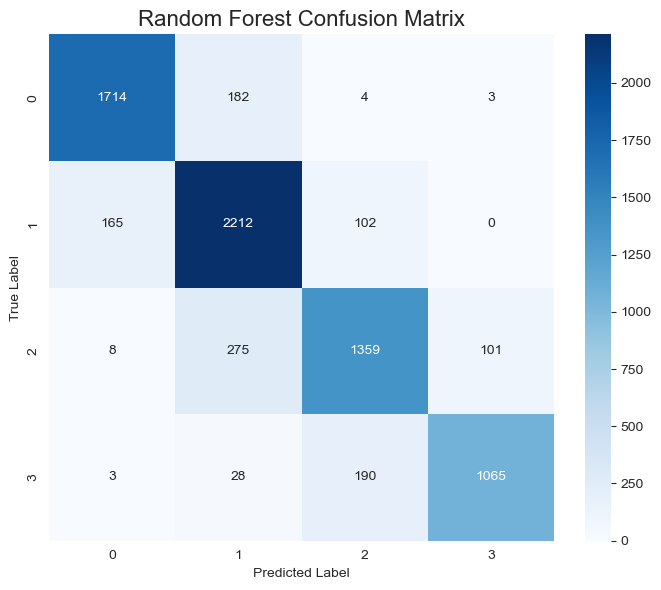


=== Feature Importance Analysis ===
Top 20 Important Features:
                           Feature  Importance
54       Total_Production_ValueNOK    0.144146
36                     Gress_dekar    0.092135
53  Production_Concentration_Index    0.068971
52        Subsidy_Dependency_Ratio    0.057548
44                         Sau_dyr    0.055149
45                      Storfe_dyr    0.052230
42                        Melk_dyr    0.051182
40                      Korn_dekar    0.049280
26                          Storfe    0.037875
21                            Melk    0.034857
76                          Storfe    0.034818
71                            Melk    0.032540
25                             Sau    0.028192
74                             Sau    0.026036
0           Kompleks_produksjon_10    0.025401
14                           Gress    0.025059
65                           Gress    0.021319
28                           Annet    0.014892
19                            Korn    0.011

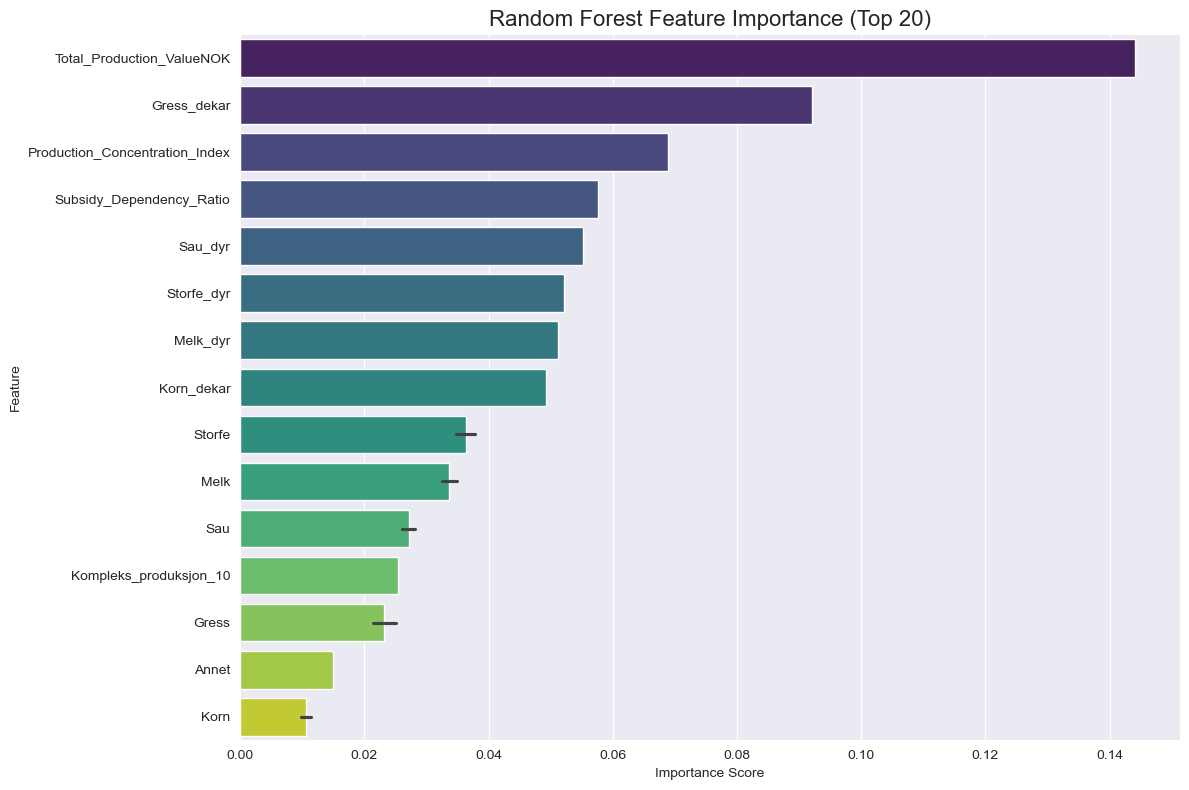

In [4]:
# --- 1. Prepare features and target ---
target_col = 'NY_tilskuddskategori'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)  # Ensure integer class labels

# --- 2. Split train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")
print(f"Class distribution:\n{y.value_counts(normalize=True)}\n")

# --- 3. Random Forest baseline ---
print("\n=== Random Forest Model ===")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)

print("✅ Random Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
try:
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')
    print("ROC AUC:", auc_rf)
except:
    print("ROC AUC cannot be computed (too many classes or imbalanced)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# --- 4. Confusion Matrix Visualization ---
print("\n=== Confusion Matrix Visualization ===")
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- 5. Feature Importance Analysis ---
print("\n=== Feature Importance Analysis ===")
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Important Features:")
print(importances.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances.head(20), palette='viridis', hue='Feature',)
plt.title('Random Forest Feature Importance (Top 20)', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()